In [2]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_theme(style="whitegrid")

In [3]:
print("--- Step 1: Downloading and Preparing Dataset ---")
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
file_path = os.path.join(path, "PJME_hourly.csv")
df = pd.read_csv(file_path)

# Standard datetime cleaning
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df = df.groupby('Datetime', as_index=False)['PJME_MW'].mean()
df.set_index('Datetime', inplace=True)

--- Step 1: Downloading and Preparing Dataset ---


In [4]:
print("--- Step 2: Mapping Custom Season and Weather Categories ---")
# 1. Map months to numerical Season values (Winter=0, Spring=1, Summer=2, Autumn=3)
def assign_season(month):
    if month in [12, 1, 2]:   return 0  
    elif month in [3, 4, 5]:  return 1  
    elif month in [6, 7, 8]:  return 2  
    else:                     return 3  

df['Month'] = df.index.month
df['Season'] = df['Month'].apply(assign_season)

# 2. Simulate Weather categories (Sunny=0, Rainy=1, Cloudy=2, Thunderstorm=3)
np.random.seed(42)
df['Weather'] = np.random.choice([0, 1, 2, 3], size=len(df), p=[0.4, 0.2, 0.3, 0.1])

# Extract basic time structures
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Year'] = df.index.year
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

--- Step 2: Mapping Custom Season and Weather Categories ---


In [5]:
print("--- Step 3: Proper Training & Testing Data Split ---")
feature_cols = ['Hour', 'Is_Weekend', 'Season', 'Weather']
target_col = 'PJME_MW'

# Chronological Split (Train on history, Test on the future)
train_df = df[df['Year'] <= 2015]
test_df = df[df['Year'] > 2015]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"• Training Set Size: {X_train.shape[0]} rows (History up to 2015)")
print(f"• Testing Set Size:  {X_test.shape[0]} rows (Future 2016-2018)")

--- Step 3: Proper Training & Testing Data Split ---
• Training Set Size: 122684 rows (History up to 2015)
• Testing Set Size:  22678 rows (Future 2016-2018)


In [6]:
print("\n--- Step 4: Model Training Phase ---")
rf_model = RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Model training completed successfully.")


--- Step 4: Model Training Phase ---
Model training completed successfully.


In [7]:
print("\n--- Step 5: Model Testing & Evaluation Phase ---")
y_pred = rf_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📊 TEST SET PERFORMANCE RESULTS:")
print(f"   • Mean Absolute Error (MAE): {mae:.2f} MW")
print(f"   • Root Mean Squared Error (RMSE): {rmse:.2f} MW")
print(f"   • R-squared (R2 Score): {r2:.4f}")
print("-" * 60)


--- Step 5: Model Testing & Evaluation Phase ---
📊 TEST SET PERFORMANCE RESULTS:
   • Mean Absolute Error (MAE): 3310.93 MW
   • Root Mean Squared Error (RMSE): 4114.68 MW
   • R-squared (R2 Score): 0.5847
------------------------------------------------------------



--- Step 6: Generating Performance Graphs ---


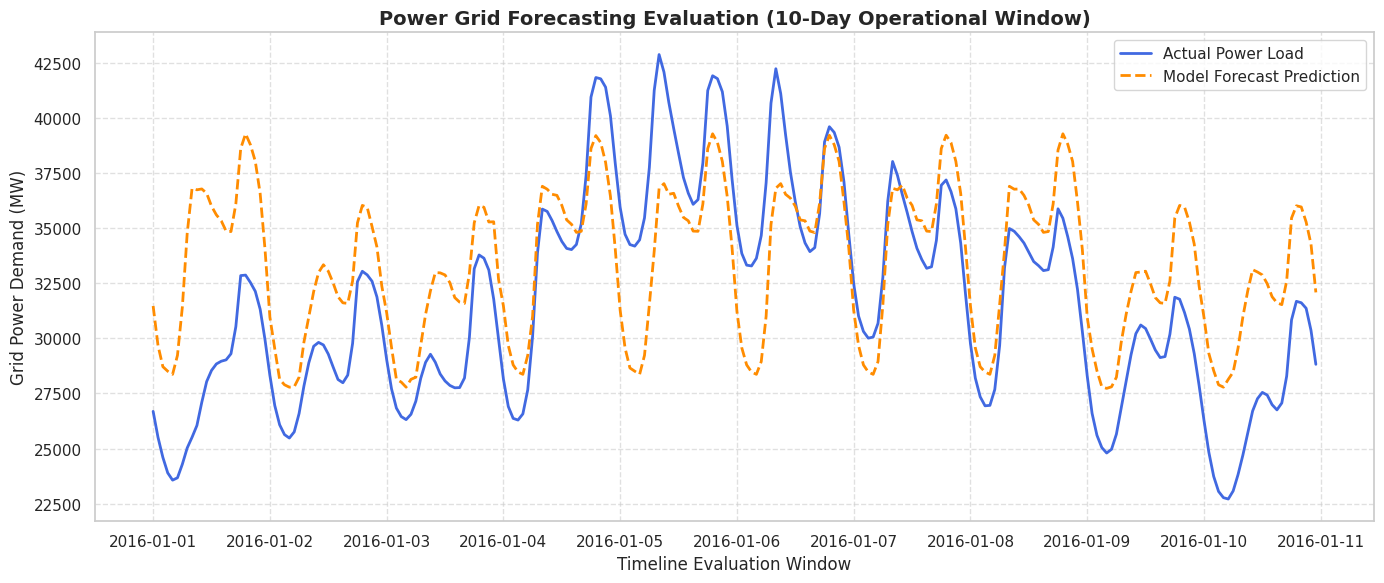

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


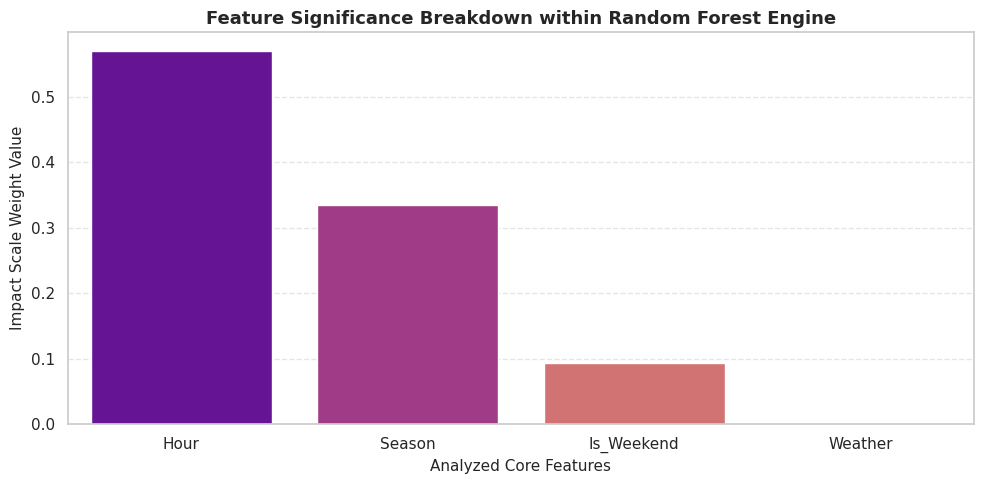

Graphs rendered smoothly in workspace dashboard preview window.
------------------------------------------------------------


In [8]:
# 📊 NEW STEP: AUTOMATED DATA VISUALIZATION GRAPH GENERATION
# =====================================================================
print("\n--- Step 6: Generating Performance Graphs ---")

# Graph A: Actual vs Predicted (10-Day Snapshot to ensure line clarity)
plt.figure(figsize=(14, 6))
snapshot_length = 240  # 24 hours * 10 days = 240 data points
plt.plot(y_test.index[:snapshot_length], y_test.iloc[:snapshot_length], label='Actual Power Load', color='royalblue', linewidth=2)
plt.plot(y_test.index[:snapshot_length], y_pred[:snapshot_length], label='Model Forecast Prediction', color='darkorange', linestyle='--', linewidth=2)

plt.title('Power Grid Forecasting Evaluation (10-Day Operational Window)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline Evaluation Window', fontsize=12)
plt.ylabel('Grid Power Demand (MW)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Graph B: Feature Importance Scoring Matrix
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=sorted_features, y=importances[indices], palette="plasma")
plt.title('Feature Significance Breakdown within Random Forest Engine', fontsize=13, fontweight='bold')
plt.xlabel('Analyzed Core Features', fontsize=11)
plt.ylabel('Impact Scale Weight Value', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Graphs rendered smoothly in workspace dashboard preview window.")
print("-" * 60)

In [9]:
# =====================================================================
# 🌐 STEP 7: INTERACTIVE TEXT-BASED SANDBOX (WITH CLOSING TAGLINE)
# =====================================================================
def run_simple_sandbox():
    print("\n" + "="*20 + " ENERGY FORECASTER SANDBOX " + "="*20)
    print("Test how different seasons, weather, and holidays affect grid load.")
    print("Type 'exit' at any time to close the program.")
    print("=" * 67)
    
    season_options = {1: ("Winter", 0), 2: ("Spring", 1), 3: ("Summer", 2), 4: ("Autumn", 3)}
    weather_options = {1: ("Sunny", 0), 2: ("Rainy", 1), 3: ("Cloudy", 2), 4: ("Thunderstorm", 3)}
    
    while True:
        try:
            # 1. Input Hour
            hour_input = input("\nEnter Hour of day (0-23) [e.g., 15 for 3 PM]: ").strip()
            if hour_input.lower() == 'exit': 
                break  # ◄ This breaks out of the loop instantly!
            user_hour = int(hour_input)
            if not (0 <= user_hour <= 23): raise ValueError("Hour must be between 0 and 23.")
            
            # 2. Input Season
            print("\nSelect Season:")
            print("1. Winter\n2. Spring\n3. Summer\n4. Autumn")
            season_choice = input("Enter choice number (1-4): ").strip()
            if season_choice.lower() == 'exit': 
                break
            season_idx = int(season_choice)
            if season_idx not in season_options: raise ValueError("Invalid choice.")
            season_name, season_encoded = season_options[season_idx]
            
            # 3. Input Weather
            print("\nSelect Weather Condition:")
            print("1. Sunny\n2. Rainy\n3. Cloudy\n4. Thunderstorm")
            weather_choice = input("Enter choice number (1-4): ").strip()
            if weather_choice.lower() == 'exit': 
                break
            weather_idx = int(weather_choice)
            if weather_idx not in weather_options: raise ValueError("Invalid choice.")
            weather_name, weather_encoded = weather_options[weather_idx]
            
            # 4. Input Holiday / Operational Status
            holiday_input = input("\nIs this a weekend or factory holiday closure? (yes/no): ").strip().lower()
            if holiday_input == 'exit': 
                break
            
            if holiday_input in ['yes', 'y', 'true']:
                user_is_weekend = 1
                status_text = "Holiday / Weekend Shutdown Mode (Factories Closed)"
            else:
                user_is_weekend = 0
                status_text = "Normal Weekday Operations (Factories Open)"
                
            # Create input row for the model matching the exact column order
            user_data = pd.DataFrame([{
                'Hour': user_hour,
                'Is_Weekend': user_is_weekend,
                'Season': season_encoded,
                'Weather': weather_encoded
            }])
            
            # Generate Prediction
            predicted_load = rf_model.predict(user_data)[0]
            
            # Display results summary
            print("\n" + "─"*55)
            print(f"📋 GRID FORECAST PROFILE:")
            print(f"   • Time Setting     : {user_hour}:00 Hours")
            print(f"   • Chosen Season    : {season_name}")
            print(f"   • Chosen Weather   : {weather_name}")
            print(f"   • Industrial Load  : {status_text}")
            print(f"🔥 ESTIMATED POWER DEMAND: {predicted_load:.2f} MW")
            print("─"*55)
            
        except ValueError as val_err:
            print(f"\n❌ Input Error: {val_err}. Please type standard numbers corresponding to options.")
        except Exception as e:
            print(f"\n❌ Error encountered: {e}. Let's try again.")

    # 🟢 EXACT PLACEMENT: Outside the 'while' loop, but inside the function definition
    print("\n💡 Optimize Usage, Save Energy, Secure the Grid! Sandbox closed safely.")

# Run the terminal interface
run_simple_sandbox()


==================== ENERGY FORECASTER SANDBOX ====================
Test how different seasons, weather, and holidays affect grid load.
Type 'exit' at any time to close the program.



Enter Hour of day (0-23) [e.g., 15 for 3 PM]:  4



Select Season:
1. Winter
2. Spring
3. Summer
4. Autumn


Enter choice number (1-4):  2



Select Weather Condition:
1. Sunny
2. Rainy
3. Cloudy
4. Thunderstorm


Enter choice number (1-4):  2

Is this a weekend or factory holiday closure? (yes/no):  yes



───────────────────────────────────────────────────────
📋 GRID FORECAST PROFILE:
   • Time Setting     : 4:00 Hours
   • Chosen Season    : Spring
   • Chosen Weather   : Rainy
   • Industrial Load  : Holiday / Weekend Shutdown Mode (Factories Closed)
🔥 ESTIMATED POWER DEMAND: 22753.39 MW
───────────────────────────────────────────────────────



Enter Hour of day (0-23) [e.g., 15 for 3 PM]:  exit



💡 Optimize Usage, Save Energy, Secure the Grid! Sandbox closed safely.


In [10]:
import joblib

# Define the file name for your saved model
model_filename = "grid_forecaster_model.pkl"

# Save (serialize) the trained model to a file
joblib.dump(rf_model, model_filename)

print(f"🎉 Success! Your Random Forest model has been saved as: '{model_filename}'")

🎉 Success! Your Random Forest model has been saved as: 'grid_forecaster_model.pkl'
